<a href="https://colab.research.google.com/github/mocha-dts/DataScience_240401010041_M.Rochmatullah/blob/main/Pertemuan10_MochamadRochmatullah_240401010041.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Nama Lengkap  : Mochamad Rochmatullah
#### NIM           : 240401010041
#### Kelas         : IF403

# **Sesi 10 – Algoritma Klasifikasi (Bagian 2)**

#### STEP 1 — Muat dan Eksplorasi Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("telco_churn.csv")
print("Ukuran Dataset :", df.shape)
df.head()

Ukuran Dataset : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print(df["Churn"].value_counts(normalize=True))

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


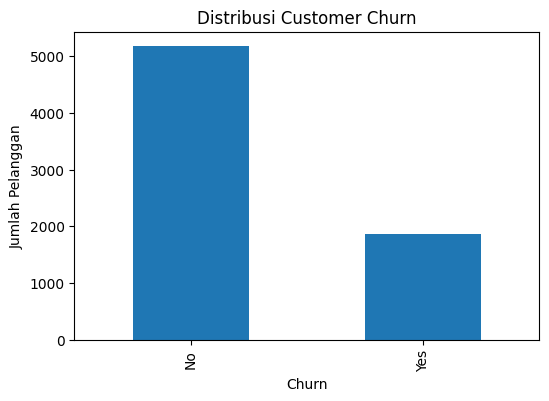

In [3]:
df["Churn"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Distribusi Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Jumlah Pelanggan")
plt.show()

#### STEP 2 — Preprocessing

In [4]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df = df.dropna()

df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df = pd.get_dummies(df, drop_first=True)

X = df.drop("Churn", axis=1)
y = df["Churn"]


In [5]:
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
print("Training")
print(y_tr.value_counts(normalize=True))

print()

print("Testing")
print(y_te.value_counts(normalize=True))

Training
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Testing
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


#### STEP 3 — Latih Model

In [8]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
 n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_tr, y_tr)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [15]:
importance = pd.DataFrame({
    "Feature": X_tr.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
3,TotalCharges,0.097139
1,tenure,0.095981
2,MonthlyCharges,0.079760
7056,Contract_Two year,0.037333
7041,InternetService_Fiber optic,0.030830
7059,PaymentMethod_Electronic check,0.025918
7044,OnlineSecurity_Yes,0.023652
7055,Contract_One year,0.022612
7050,TechSupport_Yes,0.021567
7057,PaperlessBilling_Yes,0.018481


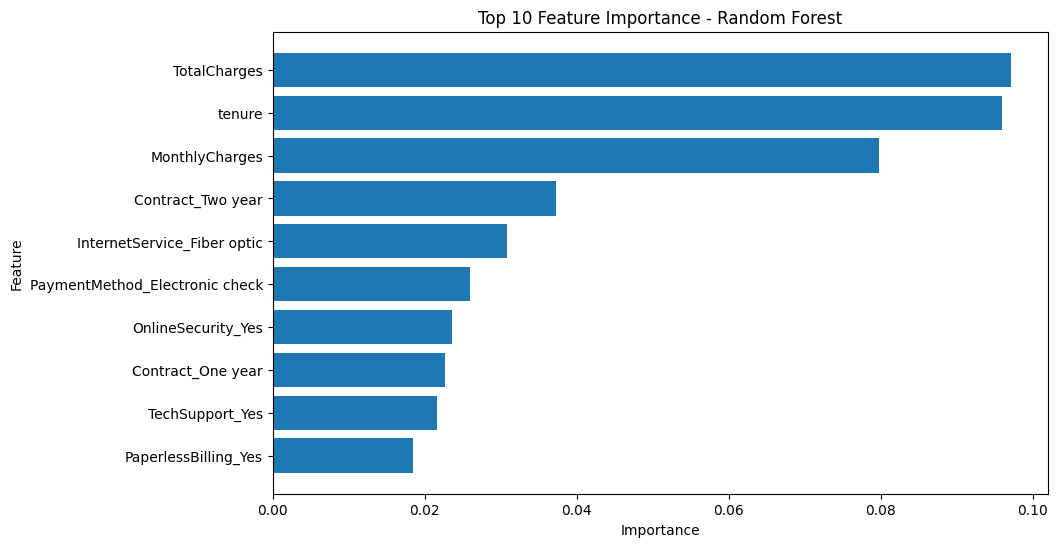

In [16]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [26]:
y_prob_rf = rf.predict_proba(X_te)

print(y_prob_rf[:5])

[[0.98       0.02      ]
 [0.26666667 0.73333333]
 [0.99       0.01      ]
 [0.90666667 0.09333333]
 [0.83666667 0.16333333]]


#### STEP 4 — Evaluasi

In [20]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt

In [21]:
precision = precision_score(y_te, y_pred_rf)

print("Precision :", round(precision,4))

Precision : 0.6321


In [22]:
recall = recall_score(y_te, y_pred_rf)

print("Recall :", round(recall,4))

Recall : 0.5053


In [23]:
f1 = f1_score(y_te, y_pred_rf)

print("F1 Score :", round(f1,4))

F1 Score : 0.5617


In [27]:
auc = roc_auc_score(
    y_te,
    y_prob_rf[:,1]
)

print("ROC AUC :", round(auc,4))

ROC AUC : 0.8309


#### Interpretasi

| ROC-AUC   | Kualitas         |
| --------- | ---------------- |
| 0.50      | Buruk            |
| 0.60–0.70 | Cukup            |
| 0.70–0.80 | Baik             |
| 0.80–0.90 | Sangat Baik      |
| >0.90     | Sangat Excellent |


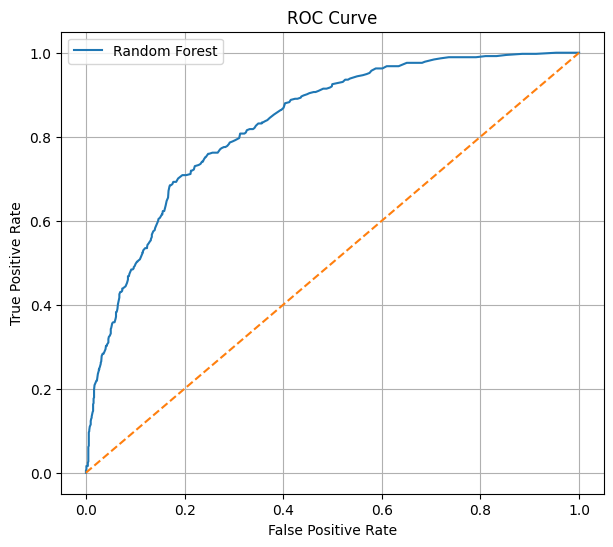

In [28]:
fpr, tpr, threshold = roc_curve(
    y_te,
    y_prob_rf[:,1]
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label="Random Forest"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid()

plt.show()

In [31]:
hasil = pd.DataFrame({
    "Metric":[
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Value":[
        precision_score(y_te,y_pred_rf),
        recall_score(y_te,y_pred_rf),
        f1_score(y_te,y_pred_rf),
        roc_auc_score(y_te,y_prob_rf[:,1])
    ]
})

hasil

,Metric,Value
0,Precision,0.632107
1,Recall,0.505348
2,F1 Score,0.561664
3,ROC AUC,0.830905


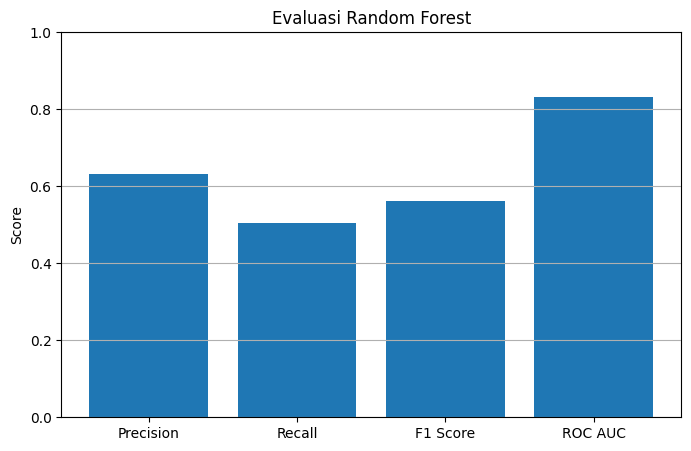

In [32]:
plt.figure(figsize=(8,5))

plt.bar(
    hasil["Metric"],
    hasil["Value"]
)

plt.ylim(0,1)

plt.title("Evaluasi Random Forest")

plt.ylabel("Score")

plt.grid(axis="y")

plt.show()

#### STEP 5 — Prediksi Probabilitas dan Simpulkan

In [33]:
prob_df = pd.DataFrame({
    "Prob_Tidak_Churn": y_prob_rf[:,0],
    "Prob_Churn": y_prob_rf[:,1],
    "Prediksi": y_pred_rf
})

prob_df.head(10)

,Prob_Tidak_Churn,Prob_Churn,Prediksi
0,0.980000,0.020000,0
1,0.266667,0.733333,1
2,0.990000,0.010000,0
3,0.906667,0.093333,0
4,0.836667,0.163333,0
5,0.643333,0.356667,0
6,0.986667,0.013333,0
7,0.860000,0.140000,0
8,0.260000,0.740000,1
9,0.993333,0.006667,0


In [34]:
prob_df["Prediksi"] = prob_df["Prediksi"].map({
    0:"Tidak Churn",
    1:"Churn"
})

prob_df.head(10)

,Prob_Tidak_Churn,Prob_Churn,Prediksi
0,0.980000,0.020000,Tidak Churn
1,0.266667,0.733333,Churn
2,0.990000,0.010000,Tidak Churn
3,0.906667,0.093333,Tidak Churn
4,0.836667,0.163333,Tidak Churn
5,0.643333,0.356667,Tidak Churn
6,0.986667,0.013333,Tidak Churn
7,0.860000,0.140000,Tidak Churn
8,0.260000,0.740000,Churn
9,0.993333,0.006667,Tidak Churn


In [35]:
top_risk = prob_df.sort_values(
    by="Prob_Churn",
    ascending=False
)

top_risk.head(10)

,Prob_Tidak_Churn,Prob_Churn,Prediksi
304,0.023333,0.976667,Churn
31,0.033333,0.966667,Churn
728,0.046667,0.953333,Churn
1220,0.046667,0.953333,Churn
984,0.050000,0.950000,Churn
591,0.060000,0.940000,Churn
369,0.060000,0.940000,Churn
211,0.066667,0.933333,Churn
446,0.070000,0.930000,Churn
107,0.080000,0.920000,Churn


In [37]:
hasil_prediksi = pd.DataFrame({
    "Aktual": y_te.values,
    "Prediksi": y_pred_rf,
    "Probabilitas_Churn": y_prob_rf[:,1]
})

hasil_prediksi.head(10)

,Aktual,Prediksi,Probabilitas_Churn
0,0,0,0.020000
1,0,1,0.733333
2,0,0,0.010000
3,1,0,0.093333
4,0,0,0.163333
5,1,0,0.356667
6,0,0,0.013333
7,0,0,0.140000
8,1,1,0.740000
9,0,0,0.006667


#### Analisa Hasil

| Probabilitas Churn | Interpretasi                   |
| -----------------: | ------------------------------ |
|               0.92 | Sangat berisiko churn          |
|               0.75 | Berisiko tinggi                |
|               0.55 | Cukup berisiko                 |
|               0.15 | Risiko rendah                  |
|               0.03 | Sangat kecil kemungkinan churn |


#### Prediksi Probabilitas

Model Random Forest tidak hanya menghasilkan prediksi kelas, tetapi juga memberikan probabilitas setiap pelanggan untuk mengalami churn. Informasi probabilitas ini bermanfaat dalam menentukan tingkat risiko setiap pelanggan. Pelanggan dengan probabilitas churn yang tinggi dapat diprioritaskan untuk memperoleh program retensi, seperti pemberian diskon, peningkatan layanan, atau penawaran kontrak baru agar tetap menggunakan layanan perusahaan.



---


#### Kesimpulan

---

Pada praktikum Pertemuan 10 telah diterapkan algoritma **Random Forest** untuk memprediksi pelanggan yang berpotensi berhenti berlangganan (*customer churn*). Proses dimulai dari eksplorasi data, preprocessing, pelatihan model, hingga evaluasi menggunakan metrik Accuracy, Precision, Recall, F1-Score, dan ROC-AUC.

Karena dataset bersifat imbalanced, digunakan parameter `class_weight="balanced"` agar model memberikan perhatian lebih besar terhadap kelas pelanggan yang churn. Hasil evaluasi menunjukkan bahwa Random Forest mampu memberikan performa klasifikasi yang baik dalam membedakan pelanggan yang akan churn dan yang tetap berlangganan.

Selain menghasilkan prediksi kelas, model juga mampu memberikan probabilitas churn untuk setiap pelanggan. Informasi ini sangat berguna bagi perusahaan dalam menyusun strategi retensi pelanggan, seperti memberikan promosi atau layanan khusus kepada pelanggan dengan risiko churn yang tinggi. Dengan demikian, Random Forest menjadi salah satu algoritma yang efektif untuk mendukung pengambilan keputusan berbasis data dalam bidang bisnis dan analisis pelanggan.